K-Means CLustering on Red Wine Quality Dataset - 5/29/2026 - aprtay2887

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"C:\Users\ecpi\Documents\winequality-red.csv")

print(data.info())
print(data.describe())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.00000

In [2]:
print("Missing Values:\n", data.isna().sum())

data = data.dropna()
data = data.drop_duplicates()

print("Shape after cleaning:", data.shape)

Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Shape after cleaning: (1359, 12)


In [3]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Standardization complete.")

Standardization complete.


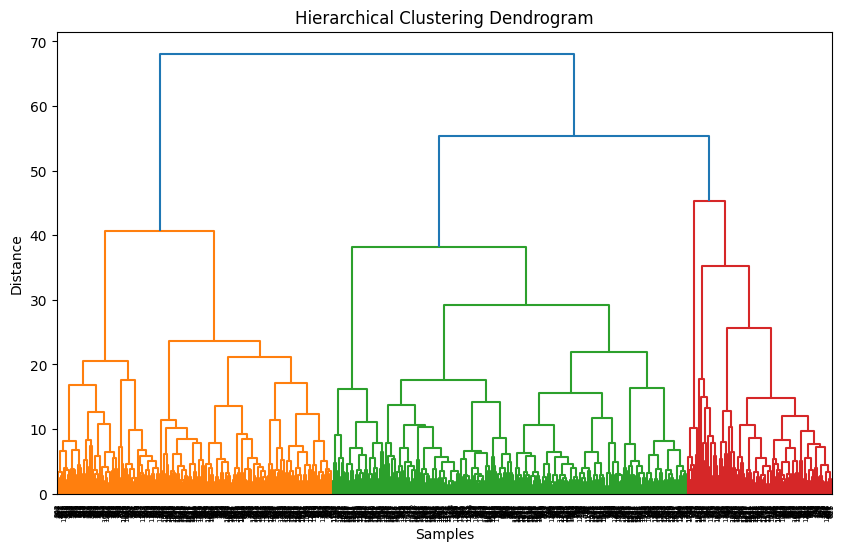

In [4]:
plt.figure(figsize=(10, 6))
linked = linkage(data_scaled, method='ward') 
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_scaled)

print("Cluster labels:")
print(kmeans.labels_[:20])

Cluster labels:
[0 0 0 1 0 0 2 0 0 0 0 1 0 0 1 1 0 1 0 0]


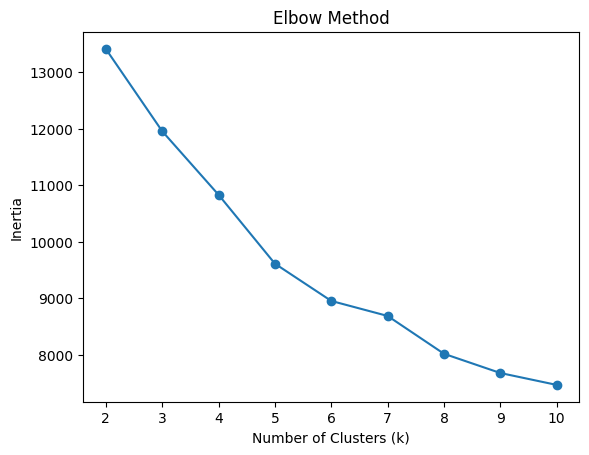

In [7]:
inertia_values = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(data_scaled)
    inertia_values.append(km.inertia_)

plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

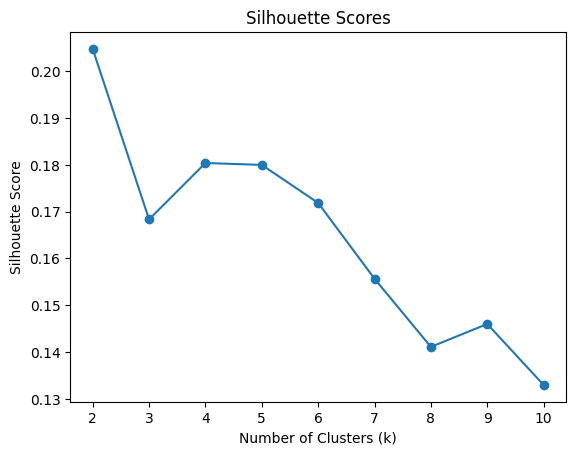

In [9]:
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(data_scaled)
    sil = silhouette_score(data_scaled, labels)
    sil_scores.append(sil)

plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [11]:
optimal_k = 3
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42)
labels_opt = kmeans_opt.fit_predict(data_scaled)

sil_opt = silhouette_score(data_scaled, labels_opt)

print("Optimal k:", optimal_k)
print("Silhouette Score:", sil_opt)

Optimal k: 3
Silhouette Score: 0.16835290781747142


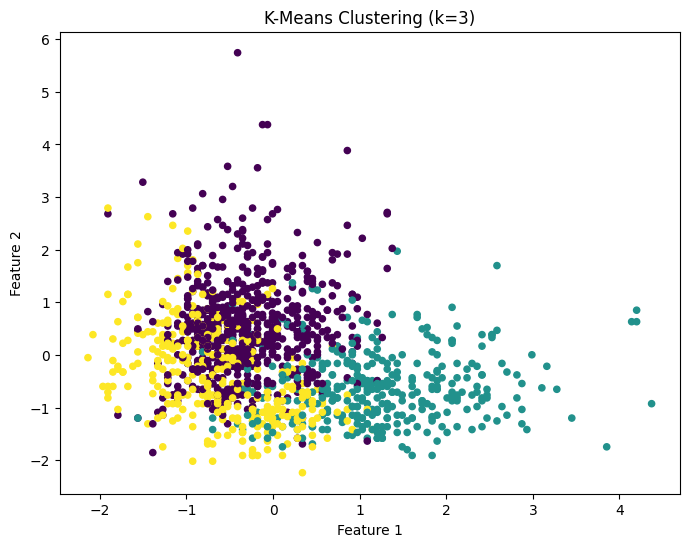

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels_opt, cmap='viridis', s=20)
plt.title(f"K-Means Clustering (k={optimal_k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

I selected 3 because the dendrogram, elbow method and silhouette score all support this value as the most balanced and interpretable number of clusters for this dataset. 
I did notive noise within the dataset. This was seen in the scatter plot as there were many points that do not belong to any cluster. This noise could be address by firstly removing any outliers and then utilizing robust scaling or using a clustering algorithm like DBSCAN which was designed to handle noisy data.